# Visualisasi Setiap Proses DETR
Notebook ini menjalankan setiap tahap DETR secara terpisah dan menampilkan output **nyata** dari gambar input.

**Struktur:**
1. Setup & Load Image
2. Backbone ResNet-50 → Feature Map
3. Proyeksi 1×1 Conv + Flatten
4. Positional Encoding
5. Transformer Encoder (Self-Attention)
6. Object Queries & Decoder
7. Feed-Forward Network (FFN)
8. Prediction Heads (Class + BBox)
9. Hasil Deteksi Final

---
## 0. Setup & Import

In [17]:
# Import dari proyek
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import torchvision.transforms as T
import torchvision.models as models
from torchvision.models import resnet50, ResNet50_Weights
import math
import warnings
warnings.filterwarnings('ignore')

from model import DETR, build_2d_sincos_position_embedding
from utils.boxes import box_cxcywh_to_xyxy, rescale_bboxes

# Konfigurasi kelas BISINDO
CLASSES = [
    'N/A',  # index 0 = no-object

    'A', 'Apa', 'Ayo', 'B', 'Baik Hati', 'Bodoh',
    'C', 'Cerewet', 'D', 'E', 'F', 'G', 'H', 'I',
    'I Love You', 'J', 'K', 'Kamu', 'Keras Kepala',
    'L', 'M', 'Makan', 'Menangis', 'N', 'Nama',
    'O', 'P', 'Pintar', 'Q', 'R', 'S', 'Saya',
    'Setia', 'Siapa', 'Sombong', 'T', 'Tidur',
    'U', 'V', 'W', 'X', 'Y', 'Z'
]

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Device: cpu
PyTorch: 2.8.0+cpu


---
## 1. Load Gambar Input
**Output:** Gambar asli yang akan diproses DETR

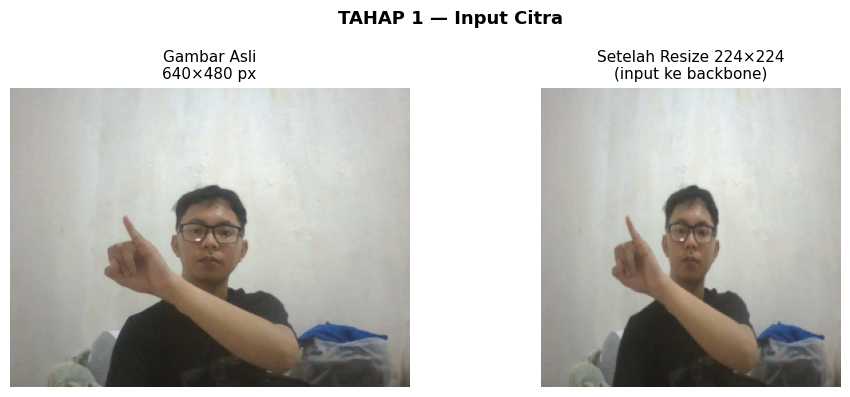


📐 Shape tensor input : torch.Size([1, 3, 224, 224])
   Format             : [batch=1, channel=3, H=224, W=224]
   Total nilai        : 150,528
   Min nilai          : -1.6898
   Max nilai          : 2.4134


In [28]:
IMAGE_PATH = '../data/mei/testing/images/0e4df7d0-I-c11bcc93-da2b-11f0-a4a8-50c2e8fdfd0c.jpg'

# Load gambar asli
img_pil = Image.open(IMAGE_PATH).convert('RGB')
W_orig, H_orig = img_pil.size

# Transform ke tensor
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])
img_tensor = transform(img_pil).unsqueeze(0).to(DEVICE) # type: ignore

# ---- Tampilkan output ----
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(img_pil)
axes[0].set_title(f'Gambar Asli\n{W_orig}×{H_orig} px', fontsize=11)
axes[0].axis('off')

axes[1].imshow(img_pil.resize((224, 224)))
axes[1].set_title('Setelah Resize 224×224\n(input ke backbone)', fontsize=11)
axes[1].axis('off')

plt.suptitle('TAHAP 1 — Input Citra', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n📐 Shape tensor input : {img_tensor.shape}')
print(f'   Format             : [batch=1, channel=3, H=224, W=224]')
print(f'   Total nilai        : {img_tensor.numel():,}')
print(f'   Min nilai          : {img_tensor.min():.4f}')
print(f'   Max nilai          : {img_tensor.max():.4f}')

---
## 2. Backbone ResNet-50 → Feature Map [1, 2048, 7, 7]
**Output:** Visualisasi feature map hasil ekstraksi ResNet-50

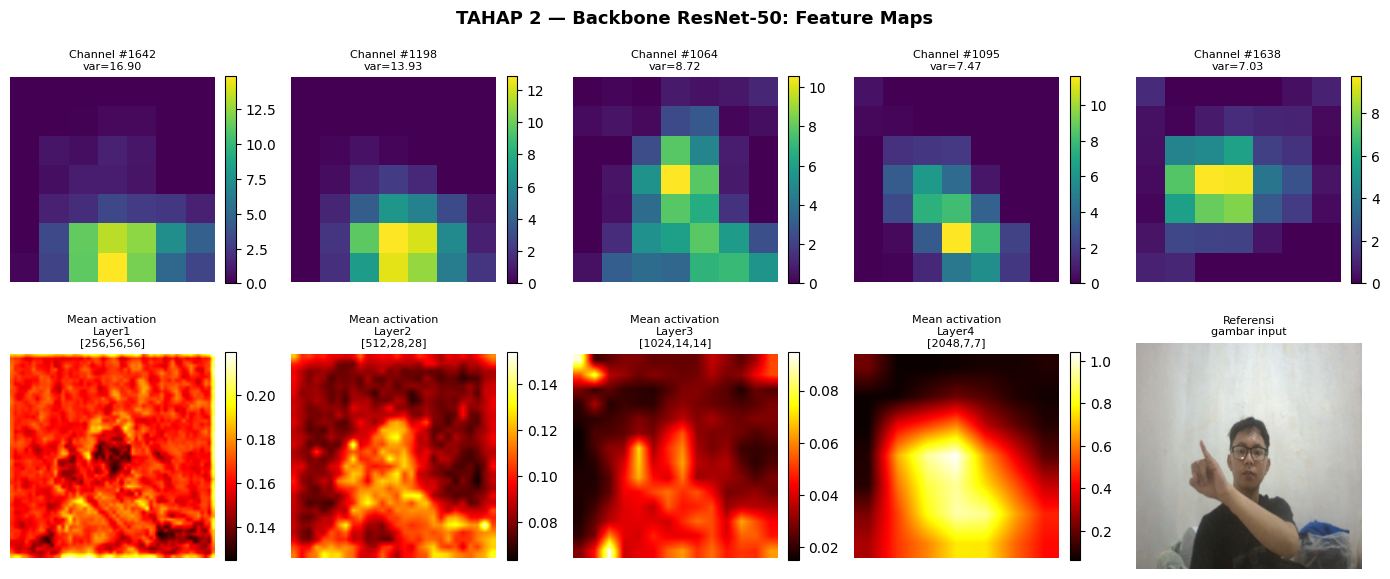


📐 Output backbone    : torch.Size([1, 2048, 7, 7])
   Format             : [batch=1, channel=2048, H=7, W=7]
   Faktor downsampling: 224 / 7 = 32×
   Min aktivasi       : 0.0000
   Max aktivasi       : 14.9321
   Mean aktivasi      : 0.4157

Downsampling per layer:
   Layer1: [1, 256, 56, 56]  →  spasial 56×56
   Layer2: [1, 512, 28, 28]  →  spasial 28×28
   Layer3: [1, 1024, 14, 14]  →  spasial 14×14
   Layer4: [1, 2048, 7, 7]  →  spasial 7×7


In [29]:
# Bangun backbone ResNet-50 (tanpa head)
backbone_full = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1).to(DEVICE)
backbone_full.eval()

# Jalankan forward step-by-step seperti di models.py
with torch.no_grad():
    x = backbone_full.conv1(img_tensor)
    x = backbone_full.bn1(x)
    x = backbone_full.relu(x)
    x = backbone_full.maxpool(x)
    feat_l1 = backbone_full.layer1(x)   # [1, 256, 56, 56]
    feat_l2 = backbone_full.layer2(feat_l1)  # [1, 512, 28, 28]
    feat_l3 = backbone_full.layer3(feat_l2)  # [1, 1024, 14, 14]
    feat_l4 = backbone_full.layer4(feat_l3)  # [1, 2048, 7, 7]  ← output backbone

feature_map = feat_l4  # [1, 2048, 7, 7]

# ---- Visualisasi ----
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

# Row atas: 8 channel feature map dari layer4 (pilih yg paling informatif)
fm = feature_map[0].cpu()  # [2048, 7, 7]

# Pilih 5 channel dengan variance tertinggi (paling informatif)
variances = fm.var(dim=[1,2])
top5_idx = variances.topk(5).indices

for i, idx in enumerate(top5_idx):
    ch = fm[idx].numpy()
    im = axes[0, i].imshow(ch, cmap='viridis', interpolation='nearest')
    axes[0, i].set_title(f'Channel #{idx}\nvar={variances[idx]:.2f}', fontsize=8)
    axes[0, i].axis('off')
    plt.colorbar(im, ax=axes[0, i], fraction=0.046)

# Row bawah: mean feature map + activation map layer1,2,3,4
for ax, (feat, lname) in zip(axes[1], [
    (feat_l1, 'Layer1\n[256,56,56]'),
    (feat_l2, 'Layer2\n[512,28,28]'),
    (feat_l3, 'Layer3\n[1024,14,14]'),
    (feat_l4, 'Layer4\n[2048,7,7]'),
]):
    mean_fm = feat[0].mean(0).cpu().numpy()
    im2 = ax.imshow(mean_fm, cmap='hot', interpolation='bilinear')
    ax.set_title(f'Mean activation\n{lname}', fontsize=8)
    ax.axis('off')
    plt.colorbar(im2, ax=ax, fraction=0.046)

# Kolom terakhir row bawah: gambar asli
axes[1, 4].imshow(img_pil.resize((224, 224)))
axes[1, 4].set_title('Referensi\ngambar input', fontsize=8)
axes[1, 4].axis('off')

plt.suptitle('TAHAP 2 — Backbone ResNet-50: Feature Maps', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n📐 Output backbone    : {feature_map.shape}')
print(f'   Format             : [batch=1, channel=2048, H=7, W=7]')
print(f'   Faktor downsampling: 224 / 7 = {224//7}×')
print(f'   Min aktivasi       : {feature_map.min():.4f}')
print(f'   Max aktivasi       : {feature_map.max():.4f}')
print(f'   Mean aktivasi      : {feature_map.mean():.4f}')
print(f'\nDownsampling per layer:')
for name, f in [('Layer1', feat_l1), ('Layer2', feat_l2),
                ('Layer3', feat_l3), ('Layer4', feat_l4)]:
    print(f'   {name}: {list(f.shape)}  →  spasial {f.shape[2]}×{f.shape[3]}')

---
## 3. Proyeksi 1×1 Conv + Flatten → [1, 49, 256]
**Output:** 49 token (7×7 flatten) masing-masing berdimensi 256

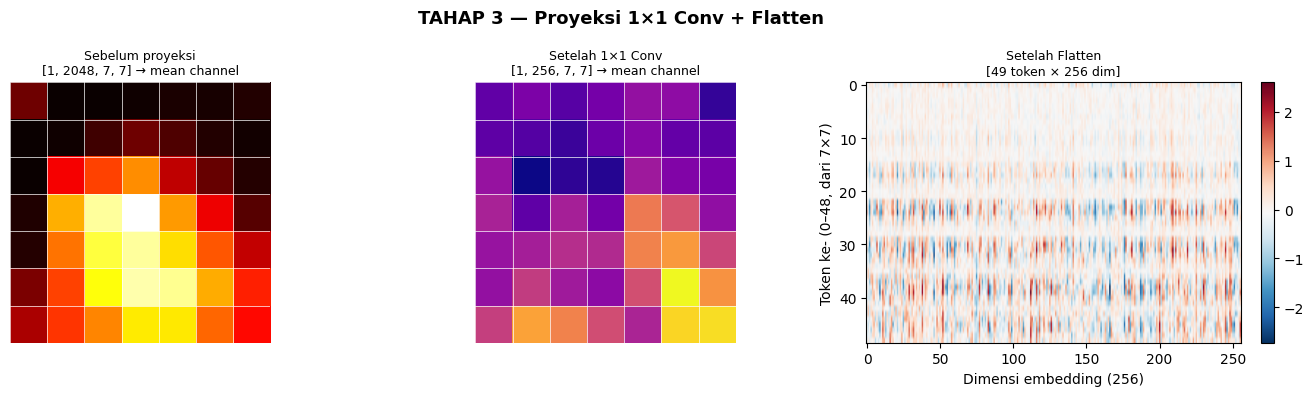


📐 Sebelum proyeksi  : torch.Size([1, 2048, 7, 7])  →  2048 channel
   Setelah 1×1 Conv  : torch.Size([1, 256, 7, 7])  →  256 channel
   Setelah flatten   : torch.Size([1, 49, 256])  →  49 token × 256 dim

Parameter 1×1 Conv:
   Weight shape      : [256, 2048, 1, 1]
   Jumlah parameter  : 2048 × 256 + 256 = 524,544

Perhitungan flatten:
   7 × 7 = 49 token spasial
   Setiap token = vektor 256-dimensi
   Token ke-i mewakili patch 32×32 px pada gambar asli


In [30]:
HIDDEN_DIM = 256

# 1×1 Conv: 2048 → 256
conv_proj = nn.Conv2d(2048, HIDDEN_DIM, kernel_size=1).to(DEVICE)
conv_proj.eval()

with torch.no_grad():
    feat_proj = conv_proj(feature_map)   # [1, 256, 7, 7]
    src = feat_proj.flatten(2).permute(0, 2, 1)  # [1, 49, 256]

# ---- Visualisasi ----
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Kiri: feature map sebelum proyeksi (mean 2048 ch)
axes[0].imshow(feature_map[0].mean(0).cpu().numpy(), cmap='hot', interpolation='nearest')
axes[0].set_title('Sebelum proyeksi\n[1, 2048, 7, 7] → mean channel', fontsize=9)
for i in range(8): axes[0].axhline(i - 0.5, color='white', lw=0.5)
for j in range(8): axes[0].axvline(j - 0.5, color='white', lw=0.5)
axes[0].axis('off')

# Tengah: feature map setelah proyeksi (mean 256 ch)
axes[1].imshow(feat_proj[0].mean(0).cpu().detach().numpy(), cmap='plasma', interpolation='nearest')
axes[1].set_title('Setelah 1×1 Conv\n[1, 256, 7, 7] → mean channel', fontsize=9)
for i in range(8): axes[1].axhline(i - 0.5, color='white', lw=0.5)
for j in range(8): axes[1].axvline(j - 0.5, color='white', lw=0.5)
axes[1].axis('off')

# Kanan: heatmap token 49×256
token_vis = src[0].cpu().detach().numpy()  # [49, 256]
im3 = axes[2].imshow(token_vis, cmap='RdBu_r', aspect='auto',
                      vmin=token_vis.min(), vmax=token_vis.max())
axes[2].set_title('Setelah Flatten\n[49 token × 256 dim]', fontsize=9)
axes[2].set_xlabel('Dimensi embedding (256)')
axes[2].set_ylabel('Token ke- (0–48, dari 7×7)')
plt.colorbar(im3, ax=axes[2], fraction=0.035)

plt.suptitle('TAHAP 3 — Proyeksi 1×1 Conv + Flatten', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n📐 Sebelum proyeksi  : {feature_map.shape}  →  2048 channel')
print(f'   Setelah 1×1 Conv  : {feat_proj.shape}  →  256 channel')
print(f'   Setelah flatten   : {src.shape}  →  49 token × 256 dim')
print(f'\nParameter 1×1 Conv:')
print(f'   Weight shape      : [256, 2048, 1, 1]')
print(f'   Jumlah parameter  : 2048 × 256 + 256 = {2048*256 + 256:,}')
print(f'\nPerhitungan flatten:')
print(f'   7 × 7 = 49 token spasial')
print(f'   Setiap token = vektor 256-dimensi')
print(f'   Token ke-i mewakili patch 32×32 px pada gambar asli')

---
## 4. Positional Encoding 2D Sinusoidal → ditambah ke src
**Output:** Visualisasi pola positional encoding + overlay pada token

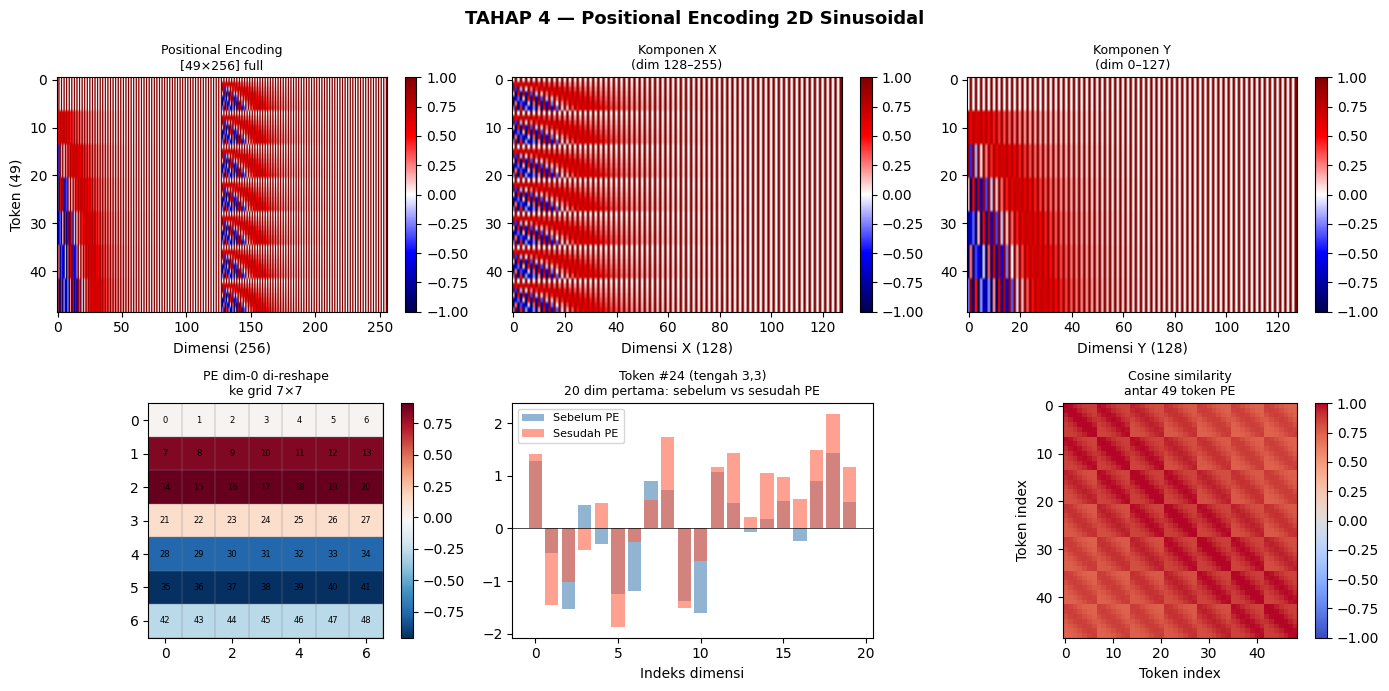


📐 PE shape           : torch.Size([1, 49, 256])
   Komponen Y        : dim 0–127  (128-dim, encode posisi baris)
   Komponen X        : dim 128–255 (128-dim, encode posisi kolom)

Contoh nilai PE token #0 (pojok kiri atas), 4 dim pertama:
   [0. 1. 0. 1.]
Contoh nilai PE token #24 (tengah), 4 dim pertama:
   [ 0.1411 -0.99    0.5173 -0.8558]

Setelah ditambah ke src:
   src shape (sebelum) : torch.Size([1, 49, 256])
   src shape (sesudah) : torch.Size([1, 49, 256])  ← sama, hanya nilai berubah


In [31]:
# Bangun positional encoding persis seperti di models.py
def _get_1d_sincos_pos_embed(length, dim, temperature=10000.0, device=None):
    assert dim % 2 == 0
    position = torch.arange(length, device=device, dtype=torch.float32).unsqueeze(1)
    div_term = torch.exp(
        torch.arange(0, dim, 2, device=device, dtype=torch.float32) * (-math.log(temperature) / dim)
    )
    pe = torch.zeros(length, dim, device=device, dtype=torch.float32)
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe

def build_2d_sincos_position_embedding(height, width, dim, device=None):
    assert dim % 2 == 0
    dim_half = dim // 2
    pe_y = _get_1d_sincos_pos_embed(height, dim_half, device=device)
    pe_x = _get_1d_sincos_pos_embed(width, dim_half, device=device)
    pos = torch.zeros(height, width, dim, device=device, dtype=torch.float32)
    pos[:, :, :dim_half] = pe_y[:, None, :].expand(-1, width, -1)
    pos[:, :, dim_half:] = pe_x[None, :, :].expand(height, -1, -1)
    return pos.view(1, height * width, dim)

pos_enc = build_2d_sincos_position_embedding(7, 7, 256, device=DEVICE)  # [1, 49, 256]
src_with_pos = src + pos_enc  # tambah ke token

# ---- Visualisasi ----
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

pe_np = pos_enc[0].cpu().numpy()  # [49, 256]

# 1. Heatmap full PE
im1 = axes[0,0].imshow(pe_np, cmap='seismic', aspect='auto', vmin=-1, vmax=1)
axes[0,0].set_title('Positional Encoding\n[49×256] full', fontsize=9)
axes[0,0].set_xlabel('Dimensi (256)')
axes[0,0].set_ylabel('Token (49)')
plt.colorbar(im1, ax=axes[0,0], fraction=0.035)

# 2. Komponen X saja (dim 128:256)
im2 = axes[0,1].imshow(pe_np[:, 128:], cmap='seismic', aspect='auto', vmin=-1, vmax=1)
axes[0,1].set_title('Komponen X\n(dim 128–255)', fontsize=9)
axes[0,1].set_xlabel('Dimensi X (128)')
plt.colorbar(im2, ax=axes[0,1], fraction=0.035)

# 3. Komponen Y saja (dim 0:128)
im3 = axes[0,2].imshow(pe_np[:, :128], cmap='seismic', aspect='auto', vmin=-1, vmax=1)
axes[0,2].set_title('Komponen Y\n(dim 0–127)', fontsize=9)
axes[0,2].set_xlabel('Dimensi Y (128)')
plt.colorbar(im3, ax=axes[0,2], fraction=0.035)

# 4. PE direstruktur ke grid 7×7 (ambil dim ke-0)
pe_grid = pe_np[:, 0].reshape(7, 7)
im4 = axes[1,0].imshow(pe_grid, cmap='RdBu_r', interpolation='nearest')
axes[1,0].set_title('PE dim-0 di-reshape\nke grid 7×7', fontsize=9)
for i in range(8): axes[1,0].axhline(i-0.5, color='gray', lw=0.3)
for j in range(8): axes[1,0].axvline(j-0.5, color='gray', lw=0.3)
for r in range(7):
    for c in range(7):
        axes[1,0].text(c, r, f'{r*7+c}', ha='center', va='center', fontsize=6, color='black')
plt.colorbar(im4, ax=axes[1,0], fraction=0.046)

# 5. src sebelum vs sesudah PE (ambil beberapa dim)
token_idx = 24  # token tengah (posisi 3,3)
dims = range(20)
axes[1,1].bar(dims, src[0, token_idx, :20].cpu().detach().numpy(),
              alpha=0.6, label='Sebelum PE', color='steelblue')
axes[1,1].bar(dims, src_with_pos[0, token_idx, :20].cpu().detach().numpy(),
              alpha=0.6, label='Sesudah PE', color='tomato')
axes[1,1].set_title(f'Token #24 (tengah 3,3)\n20 dim pertama: sebelum vs sesudah PE', fontsize=9)
axes[1,1].set_xlabel('Indeks dimensi')
axes[1,1].legend(fontsize=8)
axes[1,1].axhline(0, color='black', lw=0.5)

# 6. Cosine similarity antar token (menunjukkan posisi berbeda = encoding berbeda)
pe_norm = pe_np / (np.linalg.norm(pe_np, axis=1, keepdims=True) + 1e-8)
sim_matrix = pe_norm @ pe_norm.T  # [49, 49]
im6 = axes[1,2].imshow(sim_matrix, cmap='coolwarm', vmin=-1, vmax=1)
axes[1,2].set_title('Cosine similarity\nantar 49 token PE', fontsize=9)
axes[1,2].set_xlabel('Token index')
axes[1,2].set_ylabel('Token index')
plt.colorbar(im6, ax=axes[1,2], fraction=0.035)

plt.suptitle('TAHAP 4 — Positional Encoding 2D Sinusoidal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n📐 PE shape           : {pos_enc.shape}')
print(f'   Komponen Y        : dim 0–127  (128-dim, encode posisi baris)')
print(f'   Komponen X        : dim 128–255 (128-dim, encode posisi kolom)')
print(f'\nContoh nilai PE token #0 (pojok kiri atas), 4 dim pertama:')
print(f'   {pe_np[0, :4].round(4)}')
print(f'Contoh nilai PE token #24 (tengah), 4 dim pertama:')
print(f'   {pe_np[24, :4].round(4)}')
print(f'\nSetelah ditambah ke src:')
print(f'   src shape (sebelum) : {src.shape}')
print(f'   src shape (sesudah) : {src_with_pos.shape}  ← sama, hanya nilai berubah')

---
## 5. Transformer Encoder — Self-Attention
**Output:** Memory tensor [1, 49, 256] + visualisasi attention map

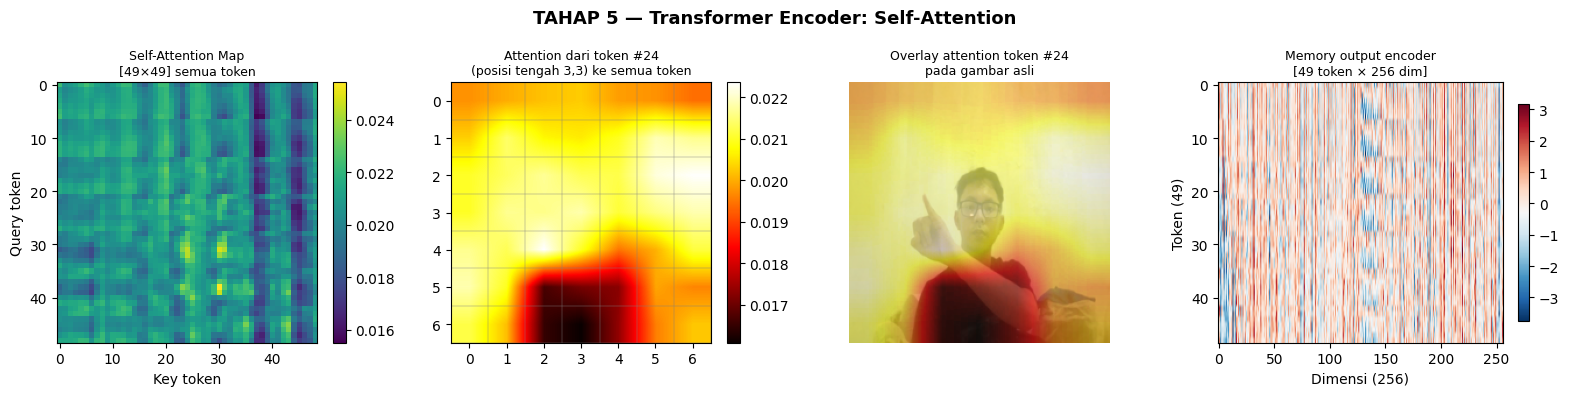


📐 Input encoder      : torch.Size([1, 49, 256])
   Output (memory)   : torch.Size([1, 49, 256])

Konfigurasi encoder:
   d_model  = 256
   n_heads  = 8  →  head_dim = 256/8 = 32
   √head_dim = √32 = 5.6569  (scaling factor)

Attention map (49×49):
   Max attention weight : 0.0254
   Min attention weight : 0.0155
   Jumlah per baris     : [1. 1. 1.]  ← softmax = 1.0


In [32]:
# Bangun encoder sesuai konfigurasi DETR
encoder_layer = nn.TransformerEncoderLayer(
    d_model=256, nhead=8, dim_feedforward=2048,
    dropout=0.1, batch_first=True
)
encoder = nn.TransformerEncoder(encoder_layer, num_layers=1).to(DEVICE)
encoder.eval()

# Ambil attention weight menggunakan hook
attn_weights = {}
def hook_fn(module, input, output):
    # TransformerEncoderLayer: output[1] = attention weights jika need_weights=True
    # Kita register hook pada self_attn
    pass

# Cara alternatif: manual multi-head attention untuk dapat attention map
mha = nn.MultiheadAttention(embed_dim=256, num_heads=8, batch_first=True).to(DEVICE)
mha.eval()

with torch.no_grad():
    # Encoder forward (untuk memory)
    memory = encoder(src_with_pos)  # [1, 49, 256]
    # Attention map secara terpisah
    _, attn_map = mha(src_with_pos, src_with_pos, src_with_pos)  # attn_map: [1, 49, 49]

attn_np = attn_map[0].cpu().numpy()   # [49, 49]
memory_np = memory[0].cpu().numpy()   # [49, 256]

# ---- Visualisasi ----
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# 1. Attention map full 49×49
im1 = axes[0].imshow(attn_np, cmap='viridis', interpolation='nearest')
axes[0].set_title('Self-Attention Map\n[49×49] semua token', fontsize=9)
axes[0].set_xlabel('Key token')
axes[0].set_ylabel('Query token')
plt.colorbar(im1, ax=axes[0], fraction=0.046)

# 2. Attention map token tengah (token 24, posisi 3,3) direstruktur ke 7×7
attn_token24 = attn_np[24].reshape(7, 7)
im2 = axes[1].imshow(attn_token24, cmap='hot', interpolation='bilinear')
axes[1].set_title('Attention dari token #24\n(posisi tengah 3,3) ke semua token', fontsize=9)
for i in range(8): axes[1].axhline(i-0.5, color='gray', lw=0.3)
for j in range(8): axes[1].axvline(j-0.5, color='gray', lw=0.3)
axes[1].set_xticks(range(7))
axes[1].set_yticks(range(7))
plt.colorbar(im2, ax=axes[1], fraction=0.046)

# 3. Overlay attention pada gambar (upscale 7×7 → 224×224)
from PIL import Image as PILImage
attn_img = PILImage.fromarray((attn_token24 / attn_token24.max() * 255).astype(np.uint8))
attn_img_up = attn_img.resize((224, 224), PILImage.BILINEAR) # type: ignore
axes[2].imshow(img_pil.resize((224, 224)))
axes[2].imshow(np.array(attn_img_up), cmap='hot', alpha=0.55)
axes[2].set_title('Overlay attention token #24\npada gambar asli', fontsize=9)
axes[2].axis('off')

# 4. Memory output heatmap
im4 = axes[3].imshow(memory_np, cmap='RdBu_r', aspect='auto')
axes[3].set_title('Memory output encoder\n[49 token × 256 dim]', fontsize=9)
axes[3].set_xlabel('Dimensi (256)')
axes[3].set_ylabel('Token (49)')
plt.colorbar(im4, ax=axes[3], fraction=0.035)

plt.suptitle('TAHAP 5 — Transformer Encoder: Self-Attention', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n📐 Input encoder      : {src_with_pos.shape}')
print(f'   Output (memory)   : {memory.shape}')
print(f'\nKonfigurasi encoder:')
print(f'   d_model  = 256')
print(f'   n_heads  = 8  →  head_dim = 256/8 = 32')
print(f'   √head_dim = √32 = {math.sqrt(32):.4f}  (scaling factor)')
print(f'\nAttention map (49×49):')
print(f'   Max attention weight : {attn_np.max():.4f}')
print(f'   Min attention weight : {attn_np.min():.4f}')
print(f'   Jumlah per baris     : {attn_np.sum(axis=1)[:3].round(3)}  ← softmax = 1.0')

---
## 6. Object Queries & Transformer Decoder
**Output:** 25 query embedding [1, 25, 256] + cross-attention map

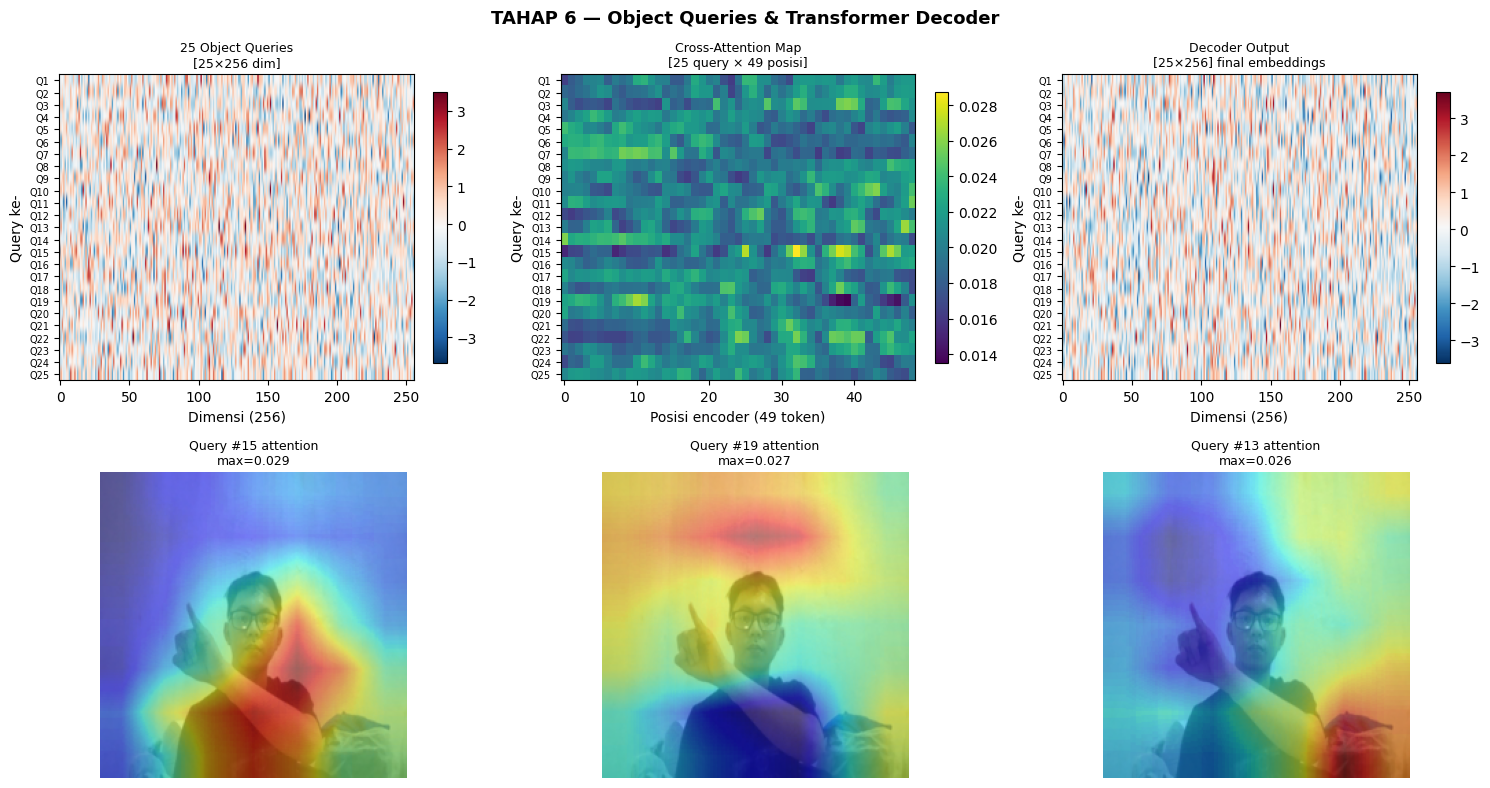


📐 Object queries     : torch.Size([1, 25, 256])  →  25 query × 256 dim
   Target (tgt_in)   : torch.Size([1, 25, 256])
   Memory (dari enc) : torch.Size([1, 49, 256])
   Decoder output    : torch.Size([1, 25, 256])

Cross-attention [25 query × 49 posisi]:
   Shape             : (25, 49)
   Sum per query     : [1. 1. 1. 1. 1.]  ← softmax = 1.0

Top-3 query paling aktif (attention tertinggi):
   Query #15: max attn=0.0288 di token #32 (grid 4,4)
   Query #19: max attn=0.0267 di token #10 (grid 1,3)
   Query #13: max attn=0.0265 di token #47 (grid 6,5)


In [33]:
NUM_QUERIES = 25

# Object queries: learnable parameter
query_pos = nn.Parameter(torch.randn(NUM_QUERIES, 256)).to(DEVICE)

# Decoder
decoder_layer = nn.TransformerDecoderLayer(
    d_model=256, nhead=8, dim_feedforward=2048,
    dropout=0.1, batch_first=True
)
decoder = nn.TransformerDecoder(decoder_layer, num_layers=1).to(DEVICE)
decoder.eval()

with torch.no_grad():
    # tgt: zero content + query positional encoding (seperti models.py)
    tgt = torch.zeros(1, NUM_QUERIES, 256, device=DEVICE)
    qpos = query_pos.unsqueeze(0).expand(1, -1, -1)  # [1, 25, 256]
    tgt_in = tgt + qpos

    # Decoder forward
    hs = decoder(tgt=tgt_in, memory=memory)  # [1, 25, 256]

    # Cross-attention map: queries attend ke memory
    mha_cross = nn.MultiheadAttention(embed_dim=256, num_heads=8, batch_first=True).to(DEVICE)
    mha_cross.eval()
    _, cross_attn = mha_cross(query=tgt_in, key=memory, value=memory)  # [1, 25, 49]

hs_np = hs[0].cpu().detach().numpy()            # [25, 256]
cross_np = cross_attn[0].cpu().detach().numpy()  # [25, 49]
qpos_np = qpos[0].cpu().detach().numpy()         # [25, 256]

# ---- Visualisasi ----
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# 1. Object queries (positional encoding)
im1 = axes[0,0].imshow(qpos_np, cmap='RdBu_r', aspect='auto')
axes[0,0].set_title('25 Object Queries\n[25×256 dim]', fontsize=9)
axes[0,0].set_xlabel('Dimensi (256)')
axes[0,0].set_ylabel('Query ke-')
axes[0,0].set_yticks(range(25))
axes[0,0].set_yticklabels([f'Q{i+1}' for i in range(25)], fontsize=7)
plt.colorbar(im1, ax=axes[0,0], fraction=0.035)

# 2. Cross-attention map [25, 49]
im2 = axes[0,1].imshow(cross_np, cmap='viridis', aspect='auto')
axes[0,1].set_title('Cross-Attention Map\n[25 query × 49 posisi]', fontsize=9)
axes[0,1].set_xlabel('Posisi encoder (49 token)')
axes[0,1].set_ylabel('Query ke-')
axes[0,1].set_yticks(range(25))
axes[0,1].set_yticklabels([f'Q{i+1}' for i in range(25)], fontsize=7)
plt.colorbar(im2, ax=axes[0,1], fraction=0.035)

# 3. Output decoder embedding [25, 256]
im3 = axes[0,2].imshow(hs_np, cmap='RdBu_r', aspect='auto')
axes[0,2].set_title('Decoder Output\n[25×256] final embeddings', fontsize=9)
axes[0,2].set_xlabel('Dimensi (256)')
axes[0,2].set_ylabel('Query ke-')
axes[0,2].set_yticks(range(25))
axes[0,2].set_yticklabels([f'Q{i+1}' for i in range(25)], fontsize=7)
plt.colorbar(im3, ax=axes[0,2], fraction=0.035)

# 4-6. Top-3 query dengan attention tertinggi overlay pada gambar
top3_queries = cross_np.max(axis=1).argsort()[-3:][::-1]
for k, q_idx in enumerate(top3_queries):
    attn_q = cross_np[q_idx].reshape(7, 7)
    attn_q_img = PILImage.fromarray(
        (attn_q / (attn_q.max() + 1e-8) * 255).astype(np.uint8)
    ).resize((224, 224), PILImage.BILINEAR) # type: ignore
    axes[1, k].imshow(img_pil.resize((224, 224)))
    axes[1, k].imshow(np.array(attn_q_img), cmap='jet', alpha=0.5)
    axes[1, k].set_title(f'Query #{q_idx+1} attention\nmax={cross_np[q_idx].max():.3f}', fontsize=9)
    axes[1, k].axis('off')

plt.suptitle('TAHAP 6 — Object Queries & Transformer Decoder', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n📐 Object queries     : {qpos.shape}  →  25 query × 256 dim')
print(f'   Target (tgt_in)   : {tgt_in.shape}')
print(f'   Memory (dari enc) : {memory.shape}')
print(f'   Decoder output    : {hs.shape}')
print(f'\nCross-attention [25 query × 49 posisi]:')
print(f'   Shape             : {cross_np.shape}')
print(f'   Sum per query     : {cross_np.sum(axis=1)[:5].round(3)}  ← softmax = 1.0')
print(f'\nTop-3 query paling aktif (attention tertinggi):')
for q in top3_queries:
    pos_max = cross_np[q].argmax()
    print(f'   Query #{q+1:02d}: max attn={cross_np[q].max():.4f} di token #{pos_max} (grid {pos_max//7},{pos_max%7})')

---
## 7. Prediction Heads — Class & BBox
**Output:** Logits 27 kelas + koordinat bounding box per query

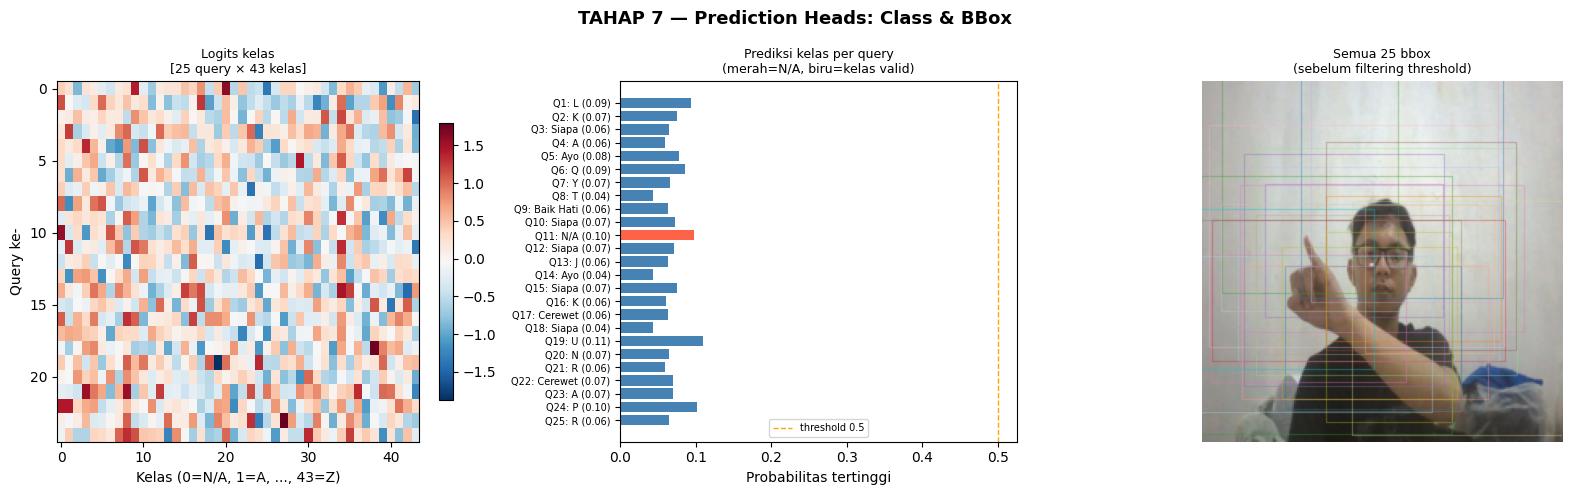


📐 Input (hs)         : torch.Size([1, 25, 256])
   Logits output     : torch.Size([1, 25, 44])  →  [1, 25, 27]
   Probs (softmax)   : torch.Size([1, 25, 44])
   Boxes (sigmoid)   : torch.Size([1, 25, 4])  →  [cx, cy, w, h] ∈ [0,1]

Parameter prediction heads:
   Class head: 256×27 + 27 = 6,939 parameter
   Box head  : 256×4  + 4  = 1,028 parameter

Contoh output 5 query pertama:
   Query    Kelas    Prob     cx       cy       w        h       
   ------------------------------------------------------------
   Q1       L        0.0939   0.5534  0.2822  0.5593  0.6312
   Q2       K        0.0746   0.4731  0.7092  0.4909  0.3955
   Q3       Siapa    0.0641   0.4608  0.5045  0.7217  0.5385
   Q4       A        0.0586   0.5853  0.5178  0.4848  0.4014
   Q5       Ayo      0.0774   0.6300  0.5467  0.3583  0.4108


In [34]:
# Prediction heads
linear_class = nn.Linear(256, 44).to(DEVICE)  # 43 kelas + 1 no-object
linear_bbox  = nn.Linear(256, 4).to(DEVICE)   # [cx, cy, w, h]
linear_class.eval()
linear_bbox.eval()

with torch.no_grad():
    logits = linear_class(hs)          # [1, 25, 43]
    probs  = logits.softmax(-1)        # [1, 25, 43]
    boxes  = linear_bbox(hs).sigmoid() # [1, 25, 4]  → [cx,cy,w,h] ∈ [0,1]

logits_np = logits[0].cpu().numpy()  # [25, 43]
probs_np  = probs[0].cpu().numpy()   # [25, 43]
boxes_np  = boxes[0].cpu().numpy()   # [25, 4]

# ---- Visualisasi ----
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Heatmap logits [25×27]
im1 = axes[0].imshow(logits_np, cmap='RdBu_r', aspect='auto')
axes[0].set_title('Logits kelas\n[25 query × 43 kelas]', fontsize=9)
axes[0].set_xlabel('Kelas (0=N/A, 1=A, ..., 43=Z)')
axes[0].set_ylabel('Query ke-')
plt.colorbar(im1, ax=axes[0], fraction=0.035)

# 2. Probabilitas kelas tertinggi per query
best_class = probs_np.argmax(axis=1)  # [25]
best_prob  = probs_np.max(axis=1)     # [25]
colors = ['tomato' if best_class[i] == 0 else 'steelblue' for i in range(25)]
bars = axes[1].barh(range(25), best_prob, color=colors)
axes[1].set_yticks(range(25))
axes[1].set_yticklabels(
    [f'Q{i+1}: {CLASSES[best_class[i]]} ({best_prob[i]:.2f})' for i in range(25)],
    fontsize=7
)
axes[1].set_xlabel('Probabilitas tertinggi')
axes[1].set_title('Prediksi kelas per query\n(merah=N/A, biru=kelas valid)', fontsize=9)
axes[1].axvline(0.5, color='orange', lw=1, linestyle='--', label='threshold 0.5')
axes[1].legend(fontsize=7)
axes[1].invert_yaxis()

# 3. Visualisasi bbox yang diprediksi (sebelum filtering)
ax3 = axes[2]
ax3.imshow(img_pil.resize((224, 224)))
ax3.set_title('Semua 25 bbox\n(sebelum filtering threshold)', fontsize=9)
ax3.axis('off')
cmap_q = plt.cm.tab20 # type: ignore
for i in range(NUM_QUERIES):
    cx, cy, w, h = boxes_np[i] * 224
    x1, y1 = cx - w/2, cy - h/2
    alpha = 0.3 + best_prob[i] * 0.5
    rect = patches.Rectangle(
        (x1, y1), w, h,
        linewidth=1, edgecolor=cmap_q(i/25),
        facecolor='none', alpha=min(alpha, 0.9)
    )
    ax3.add_patch(rect)

plt.suptitle('TAHAP 7 — Prediction Heads: Class & BBox', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n📐 Input (hs)         : {hs.shape}')
print(f'   Logits output     : {logits.shape}  →  [1, 25, 27]')
print(f'   Probs (softmax)   : {probs.shape}')
print(f'   Boxes (sigmoid)   : {boxes.shape}  →  [cx, cy, w, h] ∈ [0,1]')
print(f'\nParameter prediction heads:')
print(f'   Class head: 256×27 + 27 = {256*27+27:,} parameter')
print(f'   Box head  : 256×4  + 4  = {256*4+4:,} parameter')
print(f'\nContoh output 5 query pertama:')
print(f'   {"Query":<8} {"Kelas":<8} {"Prob":<8} {"cx":<8} {"cy":<8} {"w":<8} {"h":<8}')
print(f'   {"-"*60}')
for i in range(5):
    cx, cy, w, h = boxes_np[i]
    print(f'   Q{i+1:<7} {CLASSES[best_class[i]]:<8} {best_prob[i]:.4f}   {cx:.4f}  {cy:.4f}  {w:.4f}  {h:.4f}')

---
## 8. Hasil Deteksi Final (dengan model terlatih)
**Output:** Gambar dengan bounding box + label kelas dari model yang sudah dilatih

              🤖 DETR Model Architecture               
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Component         ┃ Details                         ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Model Type        │ DETR (Detection Transformer)    │
│ Number of Classes │ 43                              │
│ Hidden Dimension  │ 256                             │
│ Attention Heads   │ 8                               │
│ Encoder Layers    │ 1                               │
│ Decoder Layers    │ 1                               │
│ Object Queries    │ 25                              │
│ Backbone          │ ResNet-50 (ImageNet pretrained) │
└───────────────────┴─────────────────────────────────┘

✅ Checkpoint berhasil dimuat dari: ../pretrained/mei/skenario2.pt


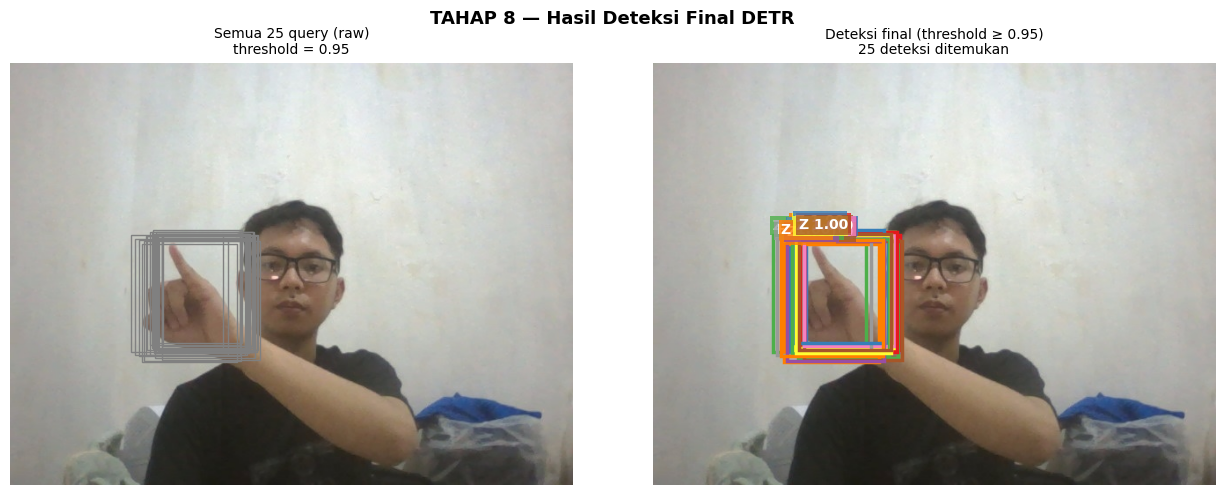


📊 Ringkasan hasil deteksi:
   Total queries     : 25
   Deteksi valid     : 25  (prob ≥ 0.95)
   Deteksi no-object : 0

   Detail deteksi:
   Query    Kelas    Score    x1       y1       x2       y2      
   --------------------------------------------------------
   Q1       Z        0.9991  161.6   194.4   272.0   324.7
   Q2       Z        0.9987  173.6   195.3   277.9   321.2
   Q3       Z        0.9971  136.6   195.2   242.0   328.2
   Q4       Z        0.9980  172.4   196.6   280.3   327.7
   Q5       Z        0.9979  158.3   192.3   260.5   320.1
   Q6       Z        0.9989  155.2   196.7   267.5   326.5
   Q7       Z        0.9987  167.8   194.5   272.8   324.3
   Q8       Z        0.9961  168.5   198.2   278.2   326.6
   Q9       Z        0.9987  167.8   199.3   275.2   328.5
   Q10      Z        0.9993  166.8   195.8   280.9   325.9
   Q11      Z        0.9970  154.4   196.1   267.2   332.2
   Q12      Z        0.9986  164.5   200.5   278.4   335.5
   Q13      Z        0.997

In [36]:
CHECKPOINT_PATH = '../pretrained/mei/skenario2.pt'  # <-- sesuaikan
THRESHOLD = 0.95  # confidence threshold

# Load model lengkap
model = DETR(
    num_classes=43,
    hidden_dim=256,
    nheads=8,
    num_encoder_layers=1,
    num_decoder_layers=1,
    num_queries=25
).to(DEVICE)

try:
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    # Sesuaikan jika checkpoint punya key 'model_state_dict'
    if 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)
    print(f'✅ Checkpoint berhasil dimuat dari: {CHECKPOINT_PATH}')
    loaded = True
except Exception as e:
    print(f'⚠️  Checkpoint tidak ditemukan: {e}')
    print('   Menjalankan dengan bobot random (hanya untuk demo alur)')
    loaded = False

model.eval()

with torch.no_grad():
    outputs = model(img_tensor)

pred_logits = outputs['pred_logits'][0]  # [25, 27]
pred_boxes  = outputs['pred_boxes'][0]   # [25, 4]
pred_probs  = pred_logits.softmax(-1)    # [25, 27]

# Filter: ambil query dengan prob kelas non-N/A > THRESHOLD
# Kolom 0 = N/A, kolom 1-26 = A-Z
keep_mask = pred_probs[:, 1:].max(-1).values > THRESHOLD
keep_idx  = keep_mask.nonzero(as_tuple=True)[0]

boxes_keep  = pred_boxes[keep_idx].cpu()
probs_keep  = pred_probs[keep_idx].cpu()
classes_keep = probs_keep[:, 1:].argmax(-1) + 1  # offset +1 karena skip N/A
scores_keep  = probs_keep[:, 1:].max(-1).values

# Rescale bbox ke ukuran gambar asli
W_img, H_img = img_pil.size
boxes_scaled = rescale_bboxes(boxes_keep, (W_img, H_img))

# ---- Visualisasi hasil akhir ----
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Kiri: semua 25 prediksi (raw)
axes[0].imshow(img_pil)
axes[0].set_title(f'Semua 25 query (raw)\nthreshold = {THRESHOLD}', fontsize=10)
axes[0].axis('off')
for i in range(NUM_QUERIES):
    cx, cy, w, h = pred_boxes[i].cpu().numpy() * np.array([W_img, H_img, W_img, H_img])
    x1, y1 = cx - w/2, cy - h/2
    p = pred_probs[i, 1:].max().item()
    alpha = max(0.1, p)
    rect = patches.Rectangle((x1, y1), w, h,
        linewidth=1, edgecolor='gray', facecolor='none', alpha=alpha)
    axes[0].add_patch(rect)

# Kanan: hasil final setelah filtering
axes[1].imshow(img_pil)
axes[1].set_title(
    f'Deteksi final (threshold ≥ {THRESHOLD})\n{len(keep_idx)} deteksi ditemukan',
    fontsize=10
)
axes[1].axis('off')

COLORS = plt.cm.Set1.colors # type: ignore
for i, (box, cls, score) in enumerate(zip(boxes_scaled, classes_keep, scores_keep)):
    x1, y1, x2, y2 = box.numpy()
    color = COLORS[i % len(COLORS)]
    rect = patches.Rectangle(
        (x1, y1), x2-x1, y2-y1,
        linewidth=2.5, edgecolor=color, facecolor='none'
    )
    axes[1].add_patch(rect)
    label = f'{CLASSES[cls.item()]} {score.item():.2f}'
    axes[1].text(x1, y1 - 6, label,
                 fontsize=10, fontweight='bold', color='white',
                 bbox=dict(facecolor=color, alpha=0.8, pad=2, edgecolor='none'))

plt.suptitle('TAHAP 8 — Hasil Deteksi Final DETR', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n📊 Ringkasan hasil deteksi:')
print(f'   Total queries     : {NUM_QUERIES}')
print(f'   Deteksi valid     : {len(keep_idx)}  (prob ≥ {THRESHOLD})')
print(f'   Deteksi no-object : {NUM_QUERIES - len(keep_idx)}')
if len(keep_idx) > 0:
    print(f'\n   Detail deteksi:')
    print(f'   {"Query":<8} {"Kelas":<8} {"Score":<8} {"x1":<8} {"y1":<8} {"x2":<8} {"y2":<8}')
    print(f'   {"-"*56}')
    for i in range(len(keep_idx)):
        x1,y1,x2,y2 = boxes_scaled[i].numpy()
        print(f'   Q{keep_idx[i].item()+1:<7} {CLASSES[classes_keep[i].item()]:<8} {scores_keep[i].item():.4f}  '
              f'{x1:.1f}   {y1:.1f}   {x2:.1f}   {y2:.1f}')

---
## 9. Ringkasan Alur Tensor
Tabel seluruh transformasi shape dari input sampai output

In [27]:
print('=' * 72)
print(f'  RINGKASAN TRANSFORMASI TENSOR — PIPELINE DETR')
print('=' * 72)
print(f'  {"Tahap":<35} {"Shape":<25} {"Keterangan"}')
print(f'  {"-"*70}')

stages = [
    ('1. Input citra (raw)',          '[1, 3, 224, 224]',  '3 channel, 224×224 px'),
    ('2. Backbone Layer1',            '[1, 256, 56, 56]',  'stride 4, 56×56 spasial'),
    ('2. Backbone Layer2',            '[1, 512, 28, 28]',  'stride 8, 28×28 spasial'),
    ('2. Backbone Layer3',            '[1, 1024, 14, 14]', 'stride 16, 14×14 spasial'),
    ('2. Backbone Layer4',            '[1, 2048, 7, 7]',   'stride 32, 7×7 spasial'),
    ('3. Setelah 1×1 Conv',           '[1, 256, 7, 7]',    '2048→256 channel'),
    ('3. Setelah flatten + permute',  '[1, 49, 256]',      '7×7=49 token'),
    ('4. Setelah +Pos. Encoding',     '[1, 49, 256]',      'shape sama, nilai berubah'),
    ('5. Encoder output (memory)',    '[1, 49, 256]',       'global context per token'),
    ('6. Object queries (tgt)',       '[1, 25, 256]',      '25 learnable queries'),
    ('6. Decoder output (hs)',        '[1, 25, 256]',      '25 final embeddings'),
    ('7. Class logits',               '[1, 25, 27]',       '26 kelas + 1 no-object'),
    ('7. Class probs (softmax)',      '[1, 25, 27]',       'sum = 1.0 per query'),
    ('7. Bbox output (sigmoid)',      '[1, 25, 4]',        '[cx, cy, w, h] ∈ [0,1]'),
    ('8. Bbox rescaled (final)',      '[N_det, 4]',        'pixel koordinat xyxy'),
]

for name, shape, note in stages:
    print(f'  {name:<35} {shape:<25} {note}')

print('=' * 72)
print(f'\n  Total parameter model DETR: 26,942,815')
print(f'  - Backbone ResNet-50      : ~23,508,032')
print(f'  - 1×1 Conv proj           :    {2048*256+256:,}')
print(f'  - Transformer (enc+dec)   : ~{256*256*4*2 + 256*2048*2:,} (approx)')
print(f'  - Prediction heads        :    {256*27+27 + 256*4+4:,}')
print(f'  - Object queries (learned):    {25*256:,}')

  RINGKASAN TRANSFORMASI TENSOR — PIPELINE DETR
  Tahap                               Shape                     Keterangan
  ----------------------------------------------------------------------
  1. Input citra (raw)                [1, 3, 224, 224]          3 channel, 224×224 px
  2. Backbone Layer1                  [1, 256, 56, 56]          stride 4, 56×56 spasial
  2. Backbone Layer2                  [1, 512, 28, 28]          stride 8, 28×28 spasial
  2. Backbone Layer3                  [1, 1024, 14, 14]         stride 16, 14×14 spasial
  2. Backbone Layer4                  [1, 2048, 7, 7]           stride 32, 7×7 spasial
  3. Setelah 1×1 Conv                 [1, 256, 7, 7]            2048→256 channel
  3. Setelah flatten + permute        [1, 49, 256]              7×7=49 token
  4. Setelah +Pos. Encoding           [1, 49, 256]              shape sama, nilai berubah
  5. Encoder output (memory)          [1, 49, 256]              global context per token
  6. Object queries (tgt)    